## RCDS Optimization

In this example we demonstrate RCDS optimization.

In [1]:
# If you encounter the "Initializing libomp.dylib, but found libomp.dylib already initialized." error
# Please run this cell
import os

In [2]:
import numpy as np
from xopt.generators.sequential import RCDSGenerator
from xopt.vocs import VOCS
from xopt.evaluator import Evaluator
from xopt import Xopt
from tqdm.auto import tqdm
import warnings


warnings.filterwarnings("ignore")

os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

In [3]:
# Reload packages automatically
%load_ext autoreload
%autoreload 2

### RCDS test problem

This test problem is a 2-D quadratic function.

In [4]:
def f_test(input_dict):
    p = []
    for i in range(2):
        p.append(input_dict[f"p{i}"])

    obj = np.linalg.norm(p)
    outcome_dict = {"f": obj}

    return outcome_dict

### Run RCDS on the test problem (YAML method)

In [5]:
YAML = """
stopping_condition:
    name: MaxEvaluationsCondition
    max_evaluations: 100
generator:
    name: rcds
    x0: null
    init_mat: null
    noise: 0.00001
    step: 0.01
    vocs:
        variables:
            p0: [0, 1]
            p1: [0, 1]
        objectives:
            f: MINIMIZE
evaluator:
    function: __main__.f_test

"""

X = Xopt.from_yaml(YAML)
X


            Xopt
________________________________
Version: 3.0.1
Data size: 0
Config as YAML:
dump_file: null
evaluator:
  function: __main__.f_test
  function_kwargs: {}
  max_workers: 1
  vectorized: false
generator:
  init_mat: null
  is_active: false
  name: rcds
  noise: 1.0e-05
  returns_id: false
  step: 0.01
  supports_single_objective: true
  vocs:
    constants: {}
    constraints: {}
    objectives:
      f:
        dtype: null
        type: MinimizeObjective
    observables: {}
    variables:
      p0:
        default_value: null
        domain:
        - 0.0
        - 1.0
        dtype: null
        type: ContinuousVariable
      p1:
        default_value: null
        domain:
        - 0.0
        - 1.0
        dtype: null
        type: ContinuousVariable
serialize_inline: false
serialize_torch: false
stopping_condition:
  count_valid_only: false
  max_evaluations: 100
  name: MaxEvaluationsCondition
  use_dataframe_index: false
strict: true


In [6]:
X.random_evaluate(1)
X.run()

Now you can go directly to the [Visualization](#Visualization) section and check out the results.

### Run RCDS on the maximization test problem (YAML method)

In [7]:
YAML = """
stopping_condition:
    name: MaxEvaluationsCondition
    max_evaluations: 400
generator:
    name: rcds
    x0: null
    init_mat: null
    noise: 1e-8
    step: 0.01
    vocs:
        variables:
            p0: [1, 3]
            p1: [-4, 2]
        objectives:
            f: MAXIMIZE
evaluator:
    function: __main__.f_test

"""

X = Xopt.from_yaml(YAML)
X


            Xopt
________________________________
Version: 3.0.1
Data size: 0
Config as YAML:
dump_file: null
evaluator:
  function: __main__.f_test
  function_kwargs: {}
  max_workers: 1
  vectorized: false
generator:
  init_mat: null
  is_active: false
  name: rcds
  noise: 1.0e-08
  returns_id: false
  step: 0.01
  supports_single_objective: true
  vocs:
    constants: {}
    constraints: {}
    objectives:
      f:
        dtype: null
        type: MaximizeObjective
    observables: {}
    variables:
      p0:
        default_value: null
        domain:
        - 1.0
        - 3.0
        dtype: null
        type: ContinuousVariable
      p1:
        default_value: null
        domain:
        - -4.0
        - 2.0
        dtype: null
        type: ContinuousVariable
serialize_inline: false
serialize_torch: false
stopping_condition:
  count_valid_only: false
  max_evaluations: 400
  name: MaxEvaluationsCondition
  use_dataframe_index: false
strict: true


In [8]:
X.random_evaluate(1)
X.run()

Now you can go directly to the [Visualization](#Visualization) section and check out the results.

### Run RCDS on the test problem (API method)

#### VOCS

We'll set the bounds for all the variables pi to [0, 1].

In [9]:
n_var = 2

In [10]:
variables = {}
for i in range(n_var):
    variables[f"p{i}"] = [0, 1]

vocs = VOCS(
    variables=variables,
    objectives={"f": "MINIMIZE"},
)

In [11]:
vocs

VOCS(variables={'p0': ContinuousVariable(dtype=None, default_value=None, domain=[0.0, 1.0]), 'p1': ContinuousVariable(dtype=None, default_value=None, domain=[0.0, 1.0])}, objectives={'f': MinimizeObjective(dtype=None)}, constraints={}, constants={}, observables={})

#### Evaluator

In [12]:
evaluator = Evaluator(function=f_test)

#### Generator

In [13]:
generator = RCDSGenerator(vocs=vocs)

In [14]:
generator.model_dump()

{'returns_id': False,
 'supports_single_objective': True,
 'vocs': {'variables': {'p0': {'dtype': None,
    'default_value': None,
    'domain': [0.0, 1.0],
    'type': 'ContinuousVariable'},
   'p1': {'dtype': None,
    'default_value': None,
    'domain': [0.0, 1.0],
    'type': 'ContinuousVariable'}},
  'objectives': {'f': {'dtype': None, 'type': 'MinimizeObjective'}},
  'constraints': {},
  'constants': {},
  'observables': {}},
 'is_active': False,
 'init_mat': None,
 'noise': 1e-05,
 'step': 0.01}

#### Run the optimization

In [15]:
X = Xopt(evaluator=evaluator, generator=generator)

In [16]:
X.evaluate_data({"p0": 0.5, "p1": 0.5})

,p0,p1,f,xopt_runtime,xopt_error
0,0.5,0.5,0.707107,0.000025,False


In [17]:
for i in tqdm(range(400)):
    X.step()

  0%|          | 0/400 [00:00<?, ?it/s]

### Visualization

<Axes: >

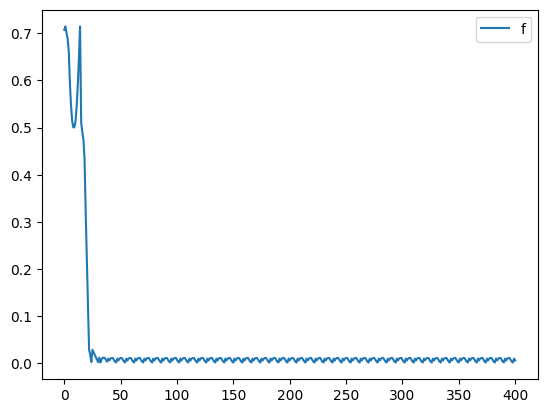

In [18]:
X.data.plot(y="f")